# Pandas - Beispiel - IMDb 

Internet Movies Database - IMDb

Referenzen:
- [Internet_Movie_Database IMDb](https://de.wikipedia.org/wiki/Internet_Movie_Database)
- [My top 25 pandas tricks](https://youtu.be/RlIiVeig3hc)

-------------------------
2026-05-11 ug V1.4

----
### Pakete laden

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Display matplotlib plots inline
%matplotlib inline

------
### IMDB movie ratings Datensatz laden

Der Datensatz [IMDB movie ratings](https://www.kaggle.com/datasets/pkabir/imdb-movie-ratings) wird aus dem Internet geladen:

"This database contains 979 rows and the following columns: star_rating, title, content_rating, genre, duration, and actors_list. 
The actors_list field is messy so it provides sample opportunity to practice text cleaning."



In [2]:
movies = pd.read_csv('http://bit.ly/imdbratings')

Zunächst geben wir uns die ersten 5 Zeilen des Datensatzes aus, um einen ersten Eindruck vom Datensatz zu bekommen.
Wir sehen 6 Spalten:
- star_rating   (10-star movie rating system [How to rate movies on IMDB](https://m.imdb.com/list/ls076459507/))
<!-- + 1/10 - ‘Do Not Want’
    + 2/10 - ‘Awful’
    + 3/10 - ‘Bad’
    + 4/10 - ‘Nice Try, But No Cigar’
    + 5/10 - ‘Meh’
    + 6/10 - ‘Not Bad’
    + 7/10 - ‘Good’
    + 8/10 - ‘Very good’
    + 9/10 - ‘Excellent’
    + 10/10 - 'Masterpiece'
-->
- title
- content_rating ([Motion Picture Association film rating system](https://en.wikipedia.org/wiki/Motion_Picture_Association_film_rating_system))
<!-- 
    + 'R', 
    + 'PG-13', 
    + 'NOT RATED', 
    + 'PG', 
    + 'UNRATED', 
    + 'APPROVED', 
    + 'PASSED',
    + 'G', 
    + 'X', 
    + 'TV-MA', 
    + 'GP', 
    + 'NC-17'
-->
- genre
- duration
- actors_list

In [3]:
movies.head()

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."


### Jetzt schauen wir wie viele Einträge der Datensatz hat

In [4]:
movies.shape

(979, 6)

979 Datensätze mit 6 Spalten.

Wie heißen die Spalten und welche Datentypen haben sie?

In [5]:
movies.columns

Index(['star_rating', 'title', 'content_rating', 'genre', 'duration',
       'actors_list'],
      dtype='str')

In [6]:
movies.dtypes

star_rating       float64
title                 str
content_rating        str
genre                 str
duration            int64
actors_list           str
dtype: object

schnelle Info

In [7]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   star_rating     979 non-null    float64
 1   title           979 non-null    str    
 2   content_rating  976 non-null    str    
 3   genre           979 non-null    str    
 4   duration        979 non-null    int64  
 5   actors_list     979 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 46.0 KB


### Gibt es fehlende Daten?

In [8]:
movies.isna()

,star_rating,title,content_rating,genre,duration,actors_list
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
974,False,False,False,False,False,False
975,False,False,False,False,False,False
976,False,False,False,False,False,False
977,False,False,False,False,False,False


In [9]:
movies.isna().any()

star_rating       False
title             False
content_rating     True
genre             False
duration          False
actors_list       False
dtype: bool

Ja, in der Spalte "content_rating" fehlen Einträge.
<br>
Wie viele Einträge fehlen?

In [10]:
movies['content_rating'].isna().sum()

np.int64(3)

Bei welchen Einträgen fehlt "content_rating"?

In [11]:
movies[movies['content_rating'].isna()]

,star_rating,title,content_rating,genre,duration,actors_list
187,8.2,Butch Cassidy and the Sundance Kid,NaN,Biography,110,"[u'Paul Newman', u'Robert Redford', u'Katharin..."
649,7.7,Where Eagles Dare,NaN,Action,158,"[u'Richard Burton', u'Clint Eastwood', u'Mary ..."
936,7.4,True Grit,NaN,Adventure,128,"[u'John Wayne', u'Kim Darby', u'Glen Campbell']"


### Export nach Excel


In [32]:
Excel_xlsx_Dateiname = r'movies.xlsx'
movies.to_excel(Excel_xlsx_Dateiname, sheet_name='movies')

### Statistik der Spalten mit kontinuierlichen Variablen:

Nur die Spalten "star_rating" und "duration" sind kontinuierlich.

In [12]:
movies.describe()

,star_rating,duration
count,979.000000,979.000000
mean,7.889785,120.979571
std,0.336069,26.218010
min,7.400000,64.000000
25%,7.600000,102.000000
50%,7.800000,117.000000
75%,8.100000,134.000000
max,9.300000,242.000000


#### Statistik über alle Spalten

In [13]:
movies.describe(include='all')

,star_rating,title,content_rating,genre,duration,actors_list
count,979.000000,979,976,979,979.000000,979
unique,NaN,975,12,16,NaN,969
top,NaN,The Girl with the Dragon Tattoo,R,Drama,NaN,"[u'Daniel Radcliffe', u'Emma Watson', u'Rupert..."
freq,NaN,2,460,278,NaN,6
mean,7.889785,NaN,NaN,NaN,120.979571,NaN
std,0.336069,NaN,NaN,NaN,26.218010,NaN
min,7.400000,NaN,NaN,NaN,64.000000,NaN
25%,7.600000,NaN,NaN,NaN,102.000000,NaN
50%,7.800000,NaN,NaN,NaN,117.000000,NaN
75%,8.100000,NaN,NaN,NaN,134.000000,NaN


### Genre

#### Wieviele Genre gibt es?

In [14]:
movies['genre'].nunique()

16

#### Welche Genre gibt es?

In [15]:
movies['genre'].unique()

<StringArray>
[    'Crime',    'Action',     'Drama',   'Western', 'Adventure', 'Biography',
    'Comedy', 'Animation',   'Mystery',    'Horror', 'Film-Noir',    'Sci-Fi',
   'History',  'Thriller',    'Family',   'Fantasy']
Length: 16, dtype: str

In [16]:
sorted(list(set(movies['genre'])))

['Action',
 'Adventure',
 'Animation',
 'Biography',
 'Comedy',
 'Crime',
 'Drama',
 'Family',
 'Fantasy',
 'Film-Noir',
 'History',
 'Horror',
 'Mystery',
 'Sci-Fi',
 'Thriller',
 'Western']

#### Wie häufig kommt jedes Genre vor?

In [17]:
movies['genre'].value_counts()

genre
Drama        278
Comedy       156
Action       136
Crime        124
Biography     77
Adventure     75
Animation     62
Horror        29
Mystery       16
Western        9
Sci-Fi         5
Thriller       5
Film-Noir      3
Family         2
History        1
Fantasy        1
Name: count, dtype: int64

#### Darstellen als Pie-Chart

<Axes: >

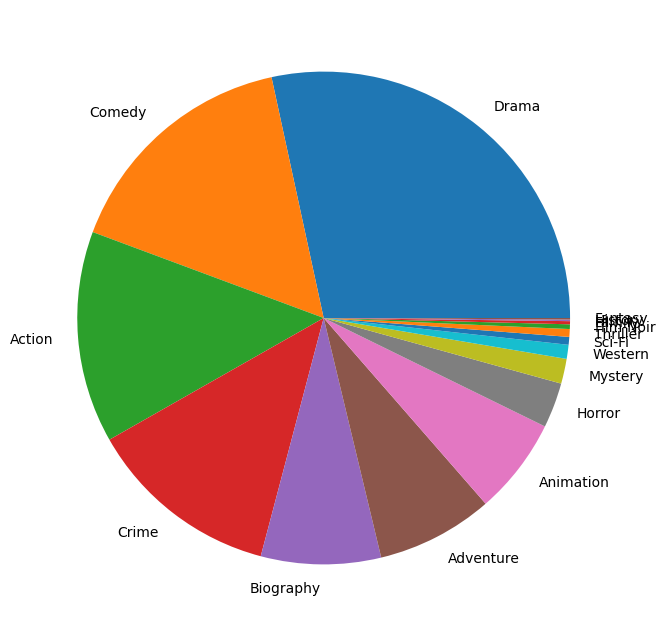

In [18]:
movies['genre'].value_counts().plot.pie(figsize=(8,8))

Welche Filme gibt es im Genre "Sci-Fi"?

In [19]:
mask = movies['genre'] == 'Sci-Fi'
movies[mask]

,star_rating,title,content_rating,genre,duration,actors_list
145,8.2,Blade Runner,R,Sci-Fi,117,"[u'Harrison Ford', u'Rutger Hauer', u'Sean You..."
321,8.0,Brazil,R,Sci-Fi,132,"[u'Jonathan Pryce', u'Kim Greist', u'Robert De..."
408,7.9,Gravity,PG-13,Sci-Fi,91,"[u'Sandra Bullock', u'George Clooney', u'Ed Ha..."
484,7.8,The Day the Earth Stood Still,APPROVED,Sci-Fi,92,"[u'Michael Rennie', u'Patricia Neal', u'Hugh M..."
637,7.7,The Butterfly Effect,R,Sci-Fi,113,"[u'Ashton Kutcher', u'Amy Smart', u'Melora Wal..."


### Content rating
#### Wie viele "content_rating"s gibt es?

In [20]:
movies["content_rating"].nunique()

12

#### Welche "content_rating"s gibt es?

In [21]:
movies["content_rating"].unique()

<StringArray>
[        'R',     'PG-13', 'NOT RATED',        'PG',   'UNRATED',  'APPROVED',
    'PASSED',         'G',         'X',         nan,     'TV-MA',        'GP',
     'NC-17']
Length: 13, dtype: str

### Star rating
#### Wie ist "star_rating" verteilt?

als Histogramm

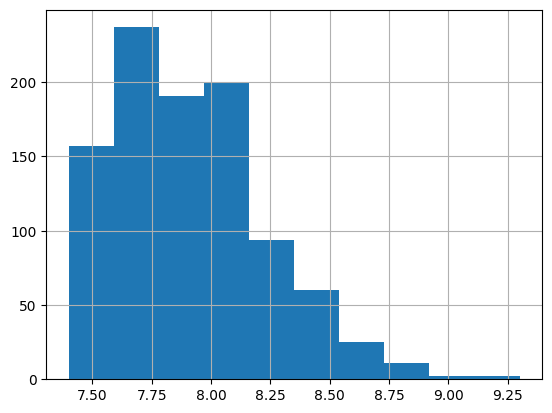

In [22]:
movies['star_rating'].hist()
plt.show()

<Axes: >

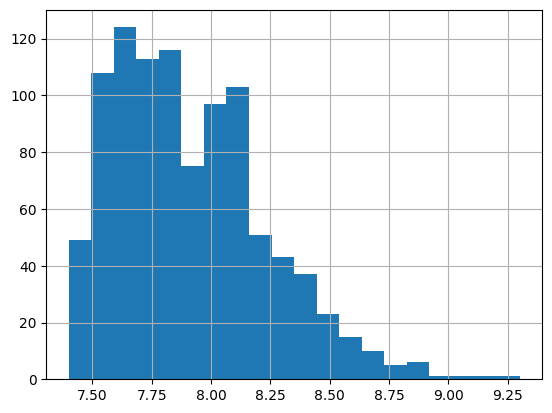

In [27]:
movies['star_rating'].hist(bins=20)

<Axes: >

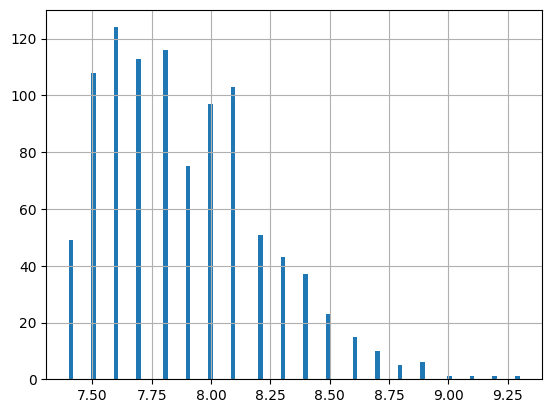

In [24]:
movies['star_rating'].hist(bins=100)

In [28]:
movies['star_rating'].min()

np.float64(7.4)

In [29]:
movies['star_rating'].median()

np.float64(7.8)

und als Boxplot

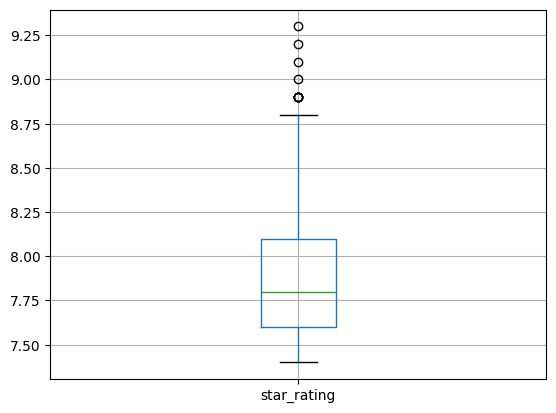

In [30]:
movies.boxplot(['star_rating'])
plt.show()

Wir sehen nur drei Filme sind besser als 9 bewertet

#### Welche Filme haben ein "star_rating" größer als 9.0?

In [31]:
mask = movies['star_rating']>9.0
movies[mask]

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."


### Spieldauer (duration)

Die Spieldauer is in Minuten angegeben.

Histogramm

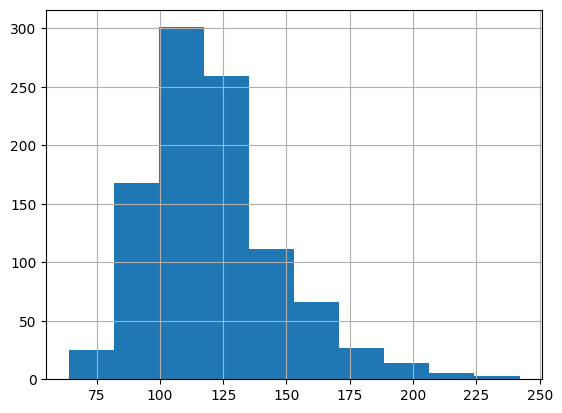

In [33]:
movies['duration'].hist()
plt.show()

und Boxplot

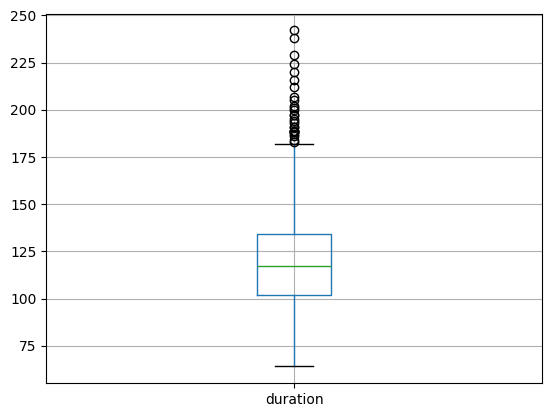

In [34]:
movies.boxplot(['duration'])
plt.show()

#### Längster Film

In [35]:
movies['duration'].max()

np.int64(242)

In [36]:
movies.loc[movies['duration'].idxmax()]

star_rating                                                     7.8
title                                                        Hamlet
content_rating                                                PG-13
genre                                                         Drama
duration                                                        242
actors_list       [u'Kenneth Branagh', u'Julie Christie', u'Dere...
Name: 476, dtype: object

In [37]:
movies.iloc[movies['duration'].argmax()]

star_rating                                                     7.8
title                                                        Hamlet
content_rating                                                PG-13
genre                                                         Drama
duration                                                        242
actors_list       [u'Kenneth Branagh', u'Julie Christie', u'Dere...
Name: 476, dtype: object

#### kürzester Film

In [38]:
movies['duration'].min()

np.int64(64)

In [39]:
movies.loc[movies['duration'].idxmin()]

star_rating                                                     8.0
title                                                        Freaks
content_rating                                              UNRATED
genre                                                         Drama
duration                                                         64
actors_list       [u'Wallace Ford', u'Leila Hyams', u'Olga Bacla...
Name: 389, dtype: object

In [40]:
movies.iloc[movies['duration'].argmin()]

star_rating                                                     8.0
title                                                        Freaks
content_rating                                              UNRATED
genre                                                         Drama
duration                                                         64
actors_list       [u'Wallace Ford', u'Leila Hyams', u'Olga Bacla...
Name: 389, dtype: object

### Top 10 der Filme aus dem Genres 'Animation' und 'Comedy'

In [41]:
mask = movies['genre'].isin(['Animation','Comedy'])
movies[mask].sort_values(by='star_rating',ascending=False)[['title','genre','star_rating','duration']].head(10)

,title,genre,star_rating,duration
25,Life Is Beautiful,Comedy,8.6,116
29,City Lights,Comedy,8.6,87
30,Spirited Away,Animation,8.6,125
35,Modern Times,Comedy,8.6,87
48,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy,8.5,95
52,The Great Dictator,Comedy,8.5,125
55,The Lion King,Animation,8.5,89
60,3 Idiots,Comedy,8.5,170
61,Grave of the Fireflies,Animation,8.5,89
64,WALL-E,Animation,8.4,98


### Die besten Filme der Genres

In [42]:
movies.groupby('genre')['star_rating'].max()

genre
Action       9.0
Adventure    8.9
Animation    8.6
Biography    8.9
Comedy       8.6
Crime        9.3
Drama        8.9
Family       7.9
Fantasy      7.7
Film-Noir    8.3
History      8.0
Horror       8.6
Mystery      8.6
Sci-Fi       8.2
Thriller     8.0
Western      8.9
Name: star_rating, dtype: float64

In [43]:
movies.loc[movies.groupby('genre')['star_rating'].idxmax()][['genre','star_rating','title']]

,genre,star_rating,title
3,Action,9.0,The Dark Knight
7,Adventure,8.9,The Lord of the Rings: The Return of the King
30,Animation,8.6,Spirited Away
8,Biography,8.9,Schindler's List
25,Comedy,8.6,Life Is Beautiful
0,Crime,9.3,The Shawshank Redemption
5,Drama,8.9,12 Angry Men
468,Family,7.9,E.T. the Extra-Terrestrial
638,Fantasy,7.7,The City of Lost Children
105,Film-Noir,8.3,The Third Man


In [44]:
movies.groupby('genre')['star_rating'].median()

genre
Action       7.80
Adventure    7.90
Animation    7.90
Biography    7.80
Comedy       7.80
Crime        7.80
Drama        7.90
Family       7.85
Fantasy      7.70
Film-Noir    8.10
History      8.00
Horror       7.70
Mystery      8.10
Sci-Fi       7.90
Thriller     7.60
Western      8.30
Name: star_rating, dtype: float64

### Filme, die im Title 'star' enthalten

In [45]:
mask = movies['title'].str.lower().str.contains('star')
movies[mask]['title']

12     Star Wars: Episode V - The Empire Strikes Back
19                                          Star Wars
80         Star Wars: Episode VI - Return of the Jedi
312                                         Star Trek
377                            The Fault in Our Stars
488                           Star Trek Into Darkness
586                   Star Trek II: The Wrath of Khan
605                                          Stardust
661      Star Wars: Episode III - Revenge of the Sith
812                          Star Trek: First Contact
Name: title, dtype: str

### Schauspieler

Jetzt wollen wir untersuchen welcher Schauspieler/in in welchem Film mitgespielt hat.
<br>
Wir schauen uns zunächste die Spalte "actors_list" an.

In [46]:
movies["actors_list"]

0      [u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...
1        [u'Marlon Brando', u'Al Pacino', u'James Caan']
2      [u'Al Pacino', u'Robert De Niro', u'Robert Duv...
3      [u'Christian Bale', u'Heath Ledger', u'Aaron E...
4      [u'John Travolta', u'Uma Thurman', u'Samuel L....
                             ...                        
974    [u'Dustin Hoffman', u'Jessica Lange', u'Teri G...
975    [u'Michael J. Fox', u'Christopher Lloyd', u'Ma...
976    [u'Russell Crowe', u'Paul Bettany', u'Billy Bo...
977    [u'JoBeth Williams', u"Heather O'Rourke", u'Cr...
978    [u'Charlie Sheen', u'Michael Douglas', u'Tamar...
Name: actors_list, Length: 979, dtype: str

Wir geben uns den Eintrag in der Spalte "actors_list" der ersten Zeile aus:

In [ ]:
actors_list_Zeile1 = movies["actors_list"].iloc[0]
print(actors_list_Zeile1)
print(f"type(actors_list_Zeile1) : {type(actors_list_Zeile1)}")

Es sieht wie eine Liste in Python aus, in der die Schauspieler als Zeichenketten enthalten sind.
Der Buchstabe u vor der Zeichenkette steht für unicode strings.

<br>
Referenzen

- [Unicode -Wikipedia](https://de.wikipedia.org/wiki/Unicode)
- [What's the u prefix in a Python string?](https://stackoverflow.com/questions/2464959/whats-the-u-prefix-in-a-python-string)
- [Unicode Strings](https://docs.python.org/2/tutorial/introduction.html#unicode-strings)
- [Unicode Homepage](https://home.unicode.org/)

Mit der in Python eingebauten [`eval`](https://realpython.com/python-eval-function/)-Funktion lassen sich Python Ausdrück während des Programmlaufs auswerten.
Wir könnten somit direkt Listen erzeugen.
<br>
**Vorsicht** Die [`eval`](https://realpython.com/python-eval-function/)-Funktion kann eine Sicherheitlücke sein, weil hiermit auch leicht Schadcode ausgeführt werden kann. Thema Cybersecurity.

In [ ]:
actors_list_Zeile_Liste = eval(actors_list_Zeile1)
print(actors_list_Zeile_Liste)
print(f"type(actors_list_Zeile_Liste) : {type(actors_list_Zeile_Liste)}")

Wir bauen jetzt einen DataFrame, welcher Schauspieler/in in welchem Film gespielt hat.

In [ ]:
MovieList = []
ActorList = []
for idx, series in movies.iterrows():
    # print(idx, series['title'], series['actors_list'].split(','))
    for actor in eval(series['actors_list']):
        actor = actor.strip()
        #print(idx, series['title'], actor)
        MovieList.append(series['title'])
        ActorList.append(actor)
#MovieList,ActorList

In [ ]:
df = pd.DataFrame(data = {'Actor':ActorList,'Movie':MovieList})
df

#### Alternative Lösung ohne [`eval`](https://realpython.com/python-eval-function/)-Funktion 
Die [`.iterrows()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html)-Methode gibt nacheinander die Zeile des Pandas DataFrame als (index, series)-Paare aus. 

In [ ]:
MovieList = []
ActorList = []
for idx, series in movies.iterrows():
    # print(idx, series['title'], series['actors_list'].split(','))
    for actor in series['actors_list'].replace('[','').replace(']','').split(','):
        actor = actor.strip()[2:-1]
        #print(idx, series['title'], actor)
        MovieList.append(series['title'])
        ActorList.append(actor)
#MovieList,ActorList

In [ ]:
df = pd.DataFrame(data = {'Actor':ActorList,'Movie':MovieList})
df

#### Schauspieler mit den meisten Filmen:

In [ ]:
df['Actor'].value_counts().head(20)

#### Anzahl der Schauspieler

In [ ]:
df['Actor'].nunique()

#### Schauspieler mit Arnold

In [ ]:
mask=df['Actor'].str.lower().str.contains('Arnold'.lower())
df[mask]